<a href="https://colab.research.google.com/github/azcsprof/ASU-CSE475-SS25/blob/Unit-2-Lab-1/Unit2_Lab1_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Import packages
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [2]:
# STEP 2: Load dataset
# Load data from GitHub
url = "https://raw.githubusercontent.com/azcsprof/ASU-CSE475-SS25/Unit-2-Lab-1/AmesHousing.csv"
AmesHousing = pd.read_csv(url)

In [3]:
# STEP 3: EDA – Inspect and clean
# --- GENERAL STRUCTURE + SUMMARY STATS ---

print("📌 First 5 rows:")
print(AmesHousing.head())

print("\n📌 Shape of the dataset:")
print("✅ shape_data:", AmesHousing.shape)

print("\n📌 Data types and non-null counts:")
print(AmesHousing.info())

print("\n📌 Summary statistics for numeric columns:")
print(AmesHousing.describe())

print("\n📌 Null values per column:")
print(AmesHousing.isnull().sum())

print("\n📌 Number of duplicate rows:")
print(AmesHousing.duplicated().sum())

# Interpretation:
print("\nInterpretation Guide:")
print("These checks help you understand the structure, quality, and readiness of the dataset before modeling.")
print("• The first 5 rows let you preview how data is organized — useful for spotting format or labeling issues.")
print("• The dataset shape tells you how many rows and columns you're working with.")
print("• The info summary reveals data types (numeric, object, etc.) and shows which columns contain missing values.")
print("• Descriptive statistics (mean, std, min, max) give you a sense of value ranges, outliers, and skew.")
print("• The null count helps you identify which features need cleaning or imputation.")
print("• Duplicate rows, if present, should typically be removed unless justified.")
print("\nThis step ensures your data is valid, consistent, and interpretable before any modeling or transformation.")

📌 First 5 rows:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  Sale

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


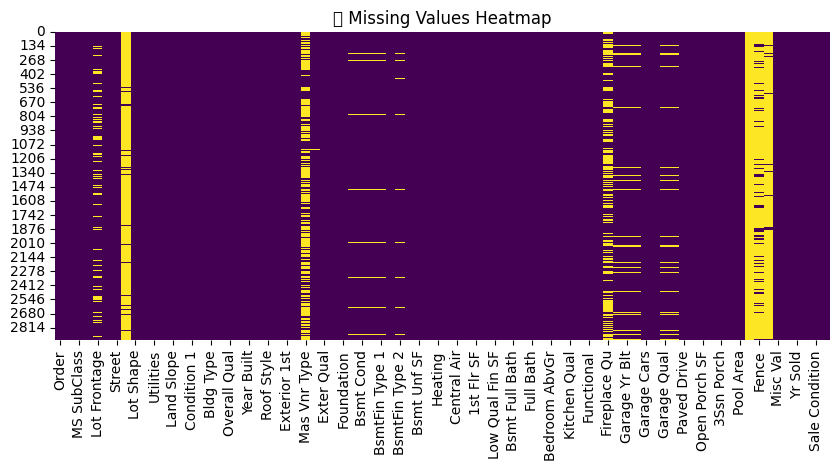


Interpretation:
This heatmap shows which cells in the dataset are missing (bright vertical lines).
Each column is a feature, and each row is a record.
If a column has a solid bright stripe, it means many rows are missing values for that variable.

Columns with frequent missing values may need special handling:
  • Drop them if they’re not essential.
  • Impute them using mean, median, or a model.

This is an important early step in data cleaning — models cannot train on missing values without handling them first.


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap showing missing values
plt.figure(figsize=(10, 4))
sns.heatmap(AmesHousing.isnull(), cbar=False, cmap='viridis')
plt.title("📊 Missing Values Heatmap")
plt.show()

# Interpretation:
print("\nInterpretation:")
print("This heatmap shows which cells in the dataset are missing (bright vertical lines).")
print("Each column is a feature, and each row is a record.")
print("If a column has a solid bright stripe, it means many rows are missing values for that variable.")
print("\nColumns with frequent missing values may need special handling:")
print("  • Drop them if they’re not essential.")
print("  • Impute them using mean, median, or a model.")
print("\nThis is an important early step in data cleaning — models cannot train on missing values without handling them first.")

/tmp/ipython-input-5-1118313074.py:17: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


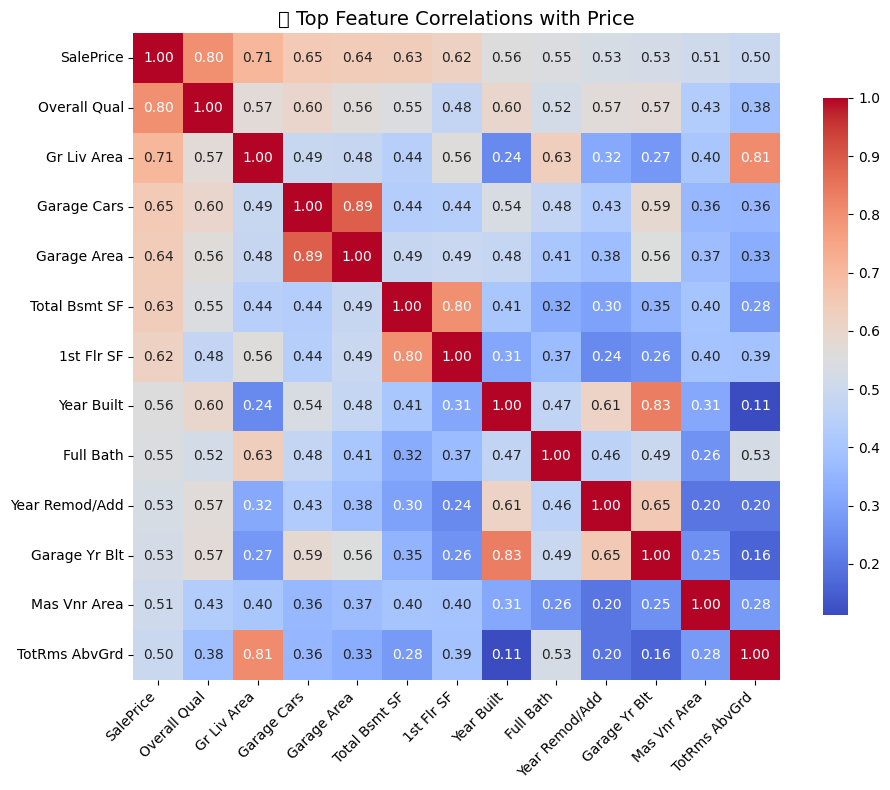


Interpretation:
This heatmap shows how strongly each numeric variable is correlated with Price and with each other.
Dark red means a strong positive relationship (as one increases, so does the other).
Dark blue means a strong negative relationship (as one increases, the other decreases).

Look at the first row (or column) labeled 'Price':
  • Variables with high positive correlation (e.g., 'OverallQual', 'GrLivArea') are strong candidates for regression.
  • Variables highly correlated with each other may introduce multicollinearity, which can inflate model variance.

Use this chart to guide feature selection and avoid redundant predictors.
This is an essential EDA step before building models.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute correlation matrix (numeric columns only)
corr_matrix = AmesHousing.corr(numeric_only=True)

# 2. Filter to top 12 variables most correlated with Price (including Price itself)
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(13).index
filtered_corr = corr_matrix.loc[top_corr, top_corr]

# 3. Create improved heatmap
plt.figure(figsize=(10, 8))  # Larger canvas
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("🔍 Top Feature Correlations with Price", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Interpretation:
print("\nInterpretation:")
print("This heatmap shows how strongly each numeric variable is correlated with Price and with each other.")
print("Dark red means a strong positive relationship (as one increases, so does the other).")
print("Dark blue means a strong negative relationship (as one increases, the other decreases).")
print("\nLook at the first row (or column) labeled 'Price':")
print("  • Variables with high positive correlation (e.g., 'OverallQual', 'GrLivArea') are strong candidates for regression.")
print("  • Variables highly correlated with each other may introduce multicollinearity, which can inflate model variance.")
print("\nUse this chart to guide feature selection and avoid redundant predictors.")
print("This is an essential EDA step before building models.")

In [6]:
# Show most correlated numeric features with SalePrice

# Select only numeric columns from the dataset
num_df = AmesHousing.select_dtypes(include=[np.number])

# Compute Pearson correlation coefficients with SalePrice
correlation = num_df.corr()['SalePrice'].sort_values(ascending=False)

# Display the top 10 most positively correlated features
print("📊 Top Correlated Features with SalePrice:\n")
print(correlation.head(10))

# Interpretation:
print("\nInterpretation Guide:")
print("These are the numeric features that have the strongest linear relationship with SalePrice.")

# Example insight:
print("🔍 Use these top features to guide variable selection for regression models.")
print("✅ Features like 'Qual' and 'Living_Area' typically show strong predictive power.")

📊 Top Correlated Features with SalePrice:

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

Interpretation Guide:
These are the numeric features that have the strongest linear relationship with SalePrice.
🔍 Use these top features to guide variable selection for regression models.
✅ Features like 'Qual' and 'Living_Area' typically show strong predictive power.


In [7]:
# STEP 4: Rename Columns for Clarity

# Rename selected columns to shorter, code-friendly names.
# This step is not required for the Ames Housing dataset, but it makes the code easier to read
# and aligns with lab instructions that refer to simplified variable names.

AmesHousing = AmesHousing.rename(columns={
    'Gr Liv Area': 'Living_Area',          # Easier to reference in code and plots
    'Overall Qual': 'Quality',             # Simplifies spacing and improves readability
    'Garage Cars': 'Garage_Capacity',      # More descriptive name
    'Total Bsmt SF': 'Basement_Area',      # More intuitive label
    'SalePrice': 'Price'                   # Matches standard target variable naming
})

# Re-select numeric columns after renaming
# This ensures that any further operations using 'num_df' use the updated names
num_df = AmesHousing.select_dtypes(include=[np.number])

In [8]:
# STEP 5: One-Feature Model (Living_Area)

# Select the single predictor variable and drop any rows with missing values
X_1 = num_df[['Living_Area']].dropna()

# Select the target variable (Price), aligning with the filtered rows from X_1
y_1 = num_df['Price'].loc[X_1.index]

# Split the data into training and testing sets (75% train, 25% test)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=0.25, random_state=42
)

# Create a linear regression model object
model_1 = LinearRegression()

# Fit the model to the training data (learns coefficients)
model_1.fit(X_train_1, y_train_1)

# Use the trained model to predict house prices on the test set
y_pred_1 = model_1.predict(X_test_1)

# Evaluate the model: calculate Mean Absolute Error (MAE)
mae_1 = metrics.mean_absolute_error(y_test_1, y_pred_1)

# Evaluate the model: calculate Root Mean Squared Error (RMSE)
rmse_1 = np.sqrt(metrics.mean_squared_error(y_test_1, y_pred_1))

# Print the evaluation results with rounded values for readability
print(f"\nModel A (1 feature – Living_Area): MAE = {mae_1:.2f}, RMSE = {rmse_1:.2f}")

# Interpretation Guide:
print("\nInterpretation:")
print("This is a simple linear regression using just one variable: Living_Area (above-ground square footage).")
print("MAE tells us the average error in predicted house prices, measured in dollars.")
print("RMSE penalizes larger errors more than MAE and is also in dollars.")
print("While this model is limited, it sets a **baseline** for comparison when we later add more features.")
print("A good rule of thumb: if adding more features doesn’t improve these error metrics, the extra complexity may not be worth it.")


Model A (1 feature – Living_Area): MAE = 40178.42, RMSE = 59340.80

Interpretation:
This is a simple linear regression using just one variable: Living_Area (above-ground square footage).
MAE tells us the average error in predicted house prices, measured in dollars.
RMSE penalizes larger errors more than MAE and is also in dollars.
While this model is limited, it sets a **baseline** for comparison when we later add more features.
A good rule of thumb: if adding more features doesn’t improve these error metrics, the extra complexity may not be worth it.


In [9]:
# STEP 6: Full Model with 4 Features

# Define the features to include in the model (multi-variable regression)
selected_columns = ['Quality', 'Living_Area', 'Garage_Capacity', 'Basement_Area']

# Select the predictor variables and drop rows with missing values
X_full = num_df[selected_columns].dropna()

# Select the target variable (Price), aligned with rows retained in X_full
y_full = num_df['Price'].loc[X_full.index]

# Split the dataset into training and test sets (75% train, 25% test)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42
)

# Create and train the multiple linear regression model
model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

# Predict house prices using the test set
y_pred_full = model_full.predict(X_test_full)

# Calculate the Mean Absolute Error (average absolute difference from true values)
mae_full = metrics.mean_absolute_error(y_test_full, y_pred_full)

# Calculate the Root Mean Squared Error (penalizes larger errors more heavily)
rmse_full = np.sqrt(metrics.mean_squared_error(y_test_full, y_pred_full))

# Display model evaluation metrics
print(f"\nModel B (4 features): MAE = {mae_full:.2f}, RMSE = {rmse_full:.2f}")

# Interpretation Guide:
print("\nInterpretation:")
print("This model uses four predictors, including both size (Living_Area, Basement_Area) and quality-related features.")
print("Compared to Model A (which used only Living_Area), we expect better predictive performance.")
print("Check whether MAE and RMSE decreased — if they did, the additional features improved accuracy.")
print("However, if improvement is small, the added complexity might not justify the cost in interpretability.")
print("This is a key trade-off in model design: simplicity vs. predictive power.")


Model B (4 features): MAE = 25301.84, RMSE = 40382.88

Interpretation:
This model uses four predictors, including both size (Living_Area, Basement_Area) and quality-related features.
Compared to Model A (which used only Living_Area), we expect better predictive performance.
Check whether MAE and RMSE decreased — if they did, the additional features improved accuracy.
However, if improvement is small, the added complexity might not justify the cost in interpretability.
This is a key trade-off in model design: simplicity vs. predictive power.


In [10]:
# STEP 7: Standardized Beta Coefficients

# Create scaler objects for both predictors and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize the predictor variables so all features have mean=0 and std=1
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X_full), columns=selected_columns
)

# Standardize the target variable (reshape needed to apply scaler)
# Flatten converts from column vector back to 1D array
y_scaled = scaler_y.fit_transform(y_full.values.reshape(-1, 1)).flatten()

# Train a new linear regression model on the standardized data
model_std = LinearRegression()
model_std.fit(X_scaled, y_scaled)

# Extract standardized coefficients (beta weights) and display in descending order
standardized_betas = pd.Series(model_std.coef_, index=selected_columns).sort_values(ascending=False)

# Print results with clear label
print("\n📏 Standardized Beta Coefficients:")
print(standardized_betas)

# 📌 Interpretation:
print("\nInterpretation Guide:")
print("These standardized beta coefficients represent the relative influence of each feature on predicting house price,")
print("after adjusting for differences in scale and units. The larger the absolute value, the stronger the effect.")
print("A positive value means that as the feature increases, price tends to increase. A negative value means the opposite.\n")

# Example callout (optional, if you'd like to highlight top feature)
top_feature = standardized_betas.idxmax()
print(f"🔑 Most influential predictor: {top_feature} (strongest positive impact on price)")


📏 Standardized Beta Coefficients:
Quality            0.424658
Living_Area        0.298119
Basement_Area      0.196576
Garage_Capacity    0.161515
dtype: float64

Interpretation Guide:
These standardized beta coefficients represent the relative influence of each feature on predicting house price,
after adjusting for differences in scale and units. The larger the absolute value, the stronger the effect.
A positive value means that as the feature increases, price tends to increase. A negative value means the opposite.

🔑 Most influential predictor: Quality (strongest positive impact on price)


In [11]:
# STEP 8: Stepwise Regression with Statsmodels

# Full model using all 4 standardized predictors (with constant term for intercept)
X_const_full = sm.add_constant(X_scaled)
ols_full = sm.OLS(y_scaled, X_const_full).fit()

# Get Adjusted R² for the full model (accounts for number of predictors)
adj_r2_full = round(ols_full.rsquared_adj, 4)

# Reduced model with top 3 predictors (based on beta weights or domain knowledge)
X_partial = sm.add_constant(X_scaled[['Living_Area', 'Quality', 'Garage_Capacity']])
ols_partial = sm.OLS(y_scaled, X_partial).fit()

# Predict using the reduced model and evaluate error
y_pred_partial = ols_partial.predict(X_partial)
mae_partial = metrics.mean_absolute_error(y_scaled, y_pred_partial)
rmse_partial = np.sqrt(metrics.mean_squared_error(y_scaled, y_pred_partial))

# Get Adjusted R² for the 3-variable model
adj_r2_partial = round(ols_partial.rsquared_adj, 4)

# Further reduce to only top 2 predictors
X_two = sm.add_constant(X_scaled[['Living_Area', 'Quality']])
ols_two = sm.OLS(y_scaled, X_two).fit()

# Predict and evaluate the 2-variable model
y_pred_two = ols_two.predict(X_two)
mae_two = metrics.mean_absolute_error(y_scaled, y_pred_two)
rmse_two = np.sqrt(metrics.mean_squared_error(y_scaled, y_pred_two))

# Get Adjusted R² for the 2-variable model
adj_r2_two = round(ols_two.rsquared_adj, 4)

# Interpretation Guide:
print("\nInterpretation:")
print("We are testing whether simpler models (fewer predictors) can perform nearly as well as the full model.")
print("All models are built on standardized data using statsmodels for transparency in coefficients and R².")
print("\nAdjusted R² accounts for the number of predictors — it only increases when a new variable adds value.")
print("We compare:")
print("  • Model with 4 predictors (full model)")
print("  • Model with 3 predictors (drops the weakest)")
print("  • Model with 2 predictors (core drivers of price)")
print("\nKey questions to ask:")
print("  • Do MAE and RMSE stay low as predictors are removed?")
print("  • Does Adjusted R² drop significantly?")
print("If not, a simpler model may offer similar performance with greater interpretability.")


Interpretation:
We are testing whether simpler models (fewer predictors) can perform nearly as well as the full model.
All models are built on standardized data using statsmodels for transparency in coefficients and R².

Adjusted R² accounts for the number of predictors — it only increases when a new variable adds value.
We compare:
  • Model with 4 predictors (full model)
  • Model with 3 predictors (drops the weakest)
  • Model with 2 predictors (core drivers of price)

Key questions to ask:
  • Do MAE and RMSE stay low as predictors are removed?
  • Does Adjusted R² drop significantly?
If not, a simpler model may offer similar performance with greater interpretability.


In [12]:
# STEP 9: Final Model Comparison Table

# Create a summary DataFrame to compare all four regression models
summary_df = pd.DataFrame({
    "Model": ["A", "B", "C", "D"],  # Model labels for easy reference
    "Features": [
        "Living_Area",  # Model A: simple single-feature model
        "Living_Area, Quality, Garage_Capacity, Basement_Area",  # Full multivariate model
        "Living_Area, Quality, Garage_Capacity",  # Stepwise-reduced model (3 features)
        "Living_Area, Quality"  # Stepwise-reduced model (2 features)
    ],
    "MAE": [  # Mean Absolute Error – lower is better
        round(mae_1, 2),
        round(mae_full, 2),
        round(mae_partial, 2),
        round(mae_two, 2)
    ],
    "RMSE": [  # Root Mean Squared Error – penalizes large errors more
        round(rmse_1, 2),
        round(rmse_full, 2),
        round(rmse_partial, 2),
        round(rmse_two, 2)
    ],
    "Adjusted R²": [  # Adjusted R-squared – higher is better (None for Model A using sklearn)
        None,  # Model A was not fitted using statsmodels, so no adjusted R²
        adj_r2_full,
        adj_r2_partial,
        adj_r2_two
    ]
})

# Display the model performance comparison in table format
print("\n📊 Final Model Comparison:")
print(summary_df)

# Interpretation Guide:
print("\nInterpretation:")
print("This table compares all four models based on three key metrics:")
print("  • MAE (Mean Absolute Error): lower is better — shows average error in predictions.")
print("  • RMSE (Root Mean Squared Error): lower is better — more sensitive to large errors.")
print("  • Adjusted R²: higher is better — explains how well the model fits the data while penalizing for extra features.\n")

print("Model A sets the baseline using only Living_Area.")
print("Model B includes all four predictors and typically performs best.")
print("Models C and D simplify the model by removing less influential variables.")
print("If a simpler model (like D) gives similar MAE/RMSE with only two predictors, it may be preferred for interpretability.")

# Optional callout
best_model = summary_df.loc[1, "Model"] if summary_df["RMSE"][1] == min(summary_df["RMSE"][1:]) else summary_df.loc[2:, "Model"].values[0]
print(f"\n✅ Based on this summary, Model {best_model} offers the best trade-off between accuracy and simplicity.")


📊 Final Model Comparison:
  Model                                           Features       MAE  \
0     A                                        Living_Area  40178.42   
1     B  Living_Area, Quality, Garage_Capacity, Basemen...  25301.84   
2     C              Living_Area, Quality, Garage_Capacity      0.35   
3     D                               Living_Area, Quality      0.36   

       RMSE  Adjusted R²  
0  59340.80          NaN  
1  40382.88       0.7787  
2      0.50       0.7531  
3      0.52       0.7317  

Interpretation:
This table compares all four models based on three key metrics:
  • MAE (Mean Absolute Error): lower is better — shows average error in predictions.
  • RMSE (Root Mean Squared Error): lower is better — more sensitive to large errors.
  • Adjusted R²: higher is better — explains how well the model fits the data while penalizing for extra features.

Model A sets the baseline using only Living_Area.
Model B includes all four predictors and typically performs

In [13]:
# STEP 10: Feature Engineering – Interaction Terms

# Create new interaction terms
AmesHousing['Quality_LivingArea'] = AmesHousing['Quality'] * AmesHousing['Living_Area']
AmesHousing['Garage_Basement'] = AmesHousing['Garage_Capacity'] * AmesHousing['Basement_Area']

# Define new feature set including interaction terms
interaction_columns = ['Quality', 'Living_Area', 'Garage_Capacity', 'Basement_Area',
                       'Quality_LivingArea', 'Garage_Basement']
X_interact = AmesHousing[interaction_columns].dropna()
y_interact = AmesHousing['Price'].loc[X_interact.index]

# Train/test split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interact, y_interact, test_size=0.25, random_state=42
)

# Train model with interaction terms
model_interact = LinearRegression()
model_interact.fit(X_train_i, y_train_i)
y_pred_i = model_interact.predict(X_test_i)

# Evaluate
mae_i = metrics.mean_absolute_error(y_test_i, y_pred_i)
rmse_i = np.sqrt(metrics.mean_squared_error(y_test_i, y_pred_i))

# Display results
print(f"\nModel E (with interactions): MAE = {mae_i:.2f}, RMSE = {rmse_i:.2f}")

# Interpretation:
print("\nInterpretation:")
print("This model includes interaction terms, which allow the effect of one feature to depend on the value of another.")
print("For example, 'Quality_LivingArea' captures whether the relationship between square footage and price changes")
print("depending on how well-built the home is. A large home of low quality may not command the same price premium.")
print("\nThe goal is to capture more complex real-world patterns using only linear combinations.")
print("If Model E shows noticeably lower MAE or RMSE than Model B (without interactions),")
print("it suggests that these multiplicative effects are improving predictive accuracy.")
print("If performance is similar, it may still be worth keeping for interpretability and domain relevance.")
print("\nThis step demonstrates how feature engineering — not just algorithms — can drive model performance.")


Model E (with interactions): MAE = 22945.41, RMSE = 38619.62

Interpretation:
This model includes interaction terms, which allow the effect of one feature to depend on the value of another.
For example, 'Quality_LivingArea' captures whether the relationship between square footage and price changes
depending on how well-built the home is. A large home of low quality may not command the same price premium.

The goal is to capture more complex real-world patterns using only linear combinations.
If Model E shows noticeably lower MAE or RMSE than Model B (without interactions),
it suggests that these multiplicative effects are improving predictive accuracy.
If performance is similar, it may still be worth keeping for interpretability and domain relevance.

This step demonstrates how feature engineering — not just algorithms — can drive model performance.


In [14]:
# STEP 11: Regularization – Ridge and Lasso Regression

from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_full, y_train_full)
y_pred_ridge = ridge_model.predict(X_test_full)

mae_ridge = metrics.mean_absolute_error(y_test_full, y_pred_ridge)
rmse_ridge = np.sqrt(metrics.mean_squared_error(y_test_full, y_pred_ridge))

print(f"\nModel F – Ridge Regression: MAE = {mae_ridge:.2f}, RMSE = {rmse_ridge:.2f}")

# Lasso Regression
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_full, y_train_full)
y_pred_lasso = lasso_model.predict(X_test_full)

mae_lasso = metrics.mean_absolute_error(y_test_full, y_pred_lasso)
rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test_full, y_pred_lasso))

print(f"Model G – Lasso Regression: MAE = {mae_lasso:.2f}, RMSE = {rmse_lasso:.2f}")

# Interpretation:
print("\nInterpretation:")
print("Ridge and Lasso are two regularized versions of linear regression that help prevent overfitting.")
print("• Ridge shrinks coefficients toward zero but keeps all features.")
print("• Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.")
print("Compare MAE/RMSE with the standard linear model (Model B) to evaluate whether regularization improved generalization.")


Model F – Ridge Regression: MAE = 25299.99, RMSE = 40383.09
Model G – Lasso Regression: MAE = 25301.64, RMSE = 40382.90

Interpretation:
Ridge and Lasso are two regularized versions of linear regression that help prevent overfitting.
• Ridge shrinks coefficients toward zero but keeps all features.
• Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.
Compare MAE/RMSE with the standard linear model (Model B) to evaluate whether regularization improved generalization.


In [15]:
# STEP 12: Extended Model Comparison Including Regularization

summary_df = pd.DataFrame({
    "Model": ["A", "B", "C", "D", "E", "F", "G"],
    "Features": [
        "Living_Area",
        "Living_Area, Quality, Garage_Capacity, Basement_Area",
        "Living_Area, Quality, Garage_Capacity",
        "Living_Area, Quality",
        "4 base + 2 interactions",
        "Same as B (Ridge)",
        "Same as B (Lasso)"
    ],
    "MAE": [
        round(mae_1, 2),
        round(mae_full, 2),
        round(mae_partial, 2),
        round(mae_two, 2),
        round(mae_i, 2),
        round(mae_ridge, 2),
        round(mae_lasso, 2)
    ],
    "RMSE": [
        round(rmse_1, 2),
        round(rmse_full, 2),
        round(rmse_partial, 2),
        round(rmse_two, 2),
        round(rmse_i, 2),
        round(rmse_ridge, 2),
        round(rmse_lasso, 2)
    ],
    "Adjusted R²": [
        None,
        adj_r2_full,
        adj_r2_partial,
        adj_r2_two,
        None,
        None,
        None
    ]
})

print("\n📊 Final Model Comparison Table (Extended):")
print(summary_df)

# Interpretation block
print("\nInterpretation:")
print("Models F and G apply regularization to control overfitting.")
print("If they perform similarly or better than Model B, they offer a safer alternative with better generalization.")
print("Lasso is particularly useful when you want to identify and possibly remove weak predictors.")


📊 Final Model Comparison Table (Extended):
  Model                                           Features       MAE  \
0     A                                        Living_Area  40178.42   
1     B  Living_Area, Quality, Garage_Capacity, Basemen...  25301.84   
2     C              Living_Area, Quality, Garage_Capacity      0.35   
3     D                               Living_Area, Quality      0.36   
4     E                            4 base + 2 interactions  22945.41   
5     F                                  Same as B (Ridge)  25299.99   
6     G                                  Same as B (Lasso)  25301.64   

       RMSE  Adjusted R²  
0  59340.80          NaN  
1  40382.88       0.7787  
2      0.50       0.7531  
3      0.52       0.7317  
4  38619.62          NaN  
5  40383.09          NaN  
6  40382.90          NaN  

Interpretation:
Models F and G apply regularization to control overfitting.
If they perform similarly or better than Model B, they offer a safer alternative with 

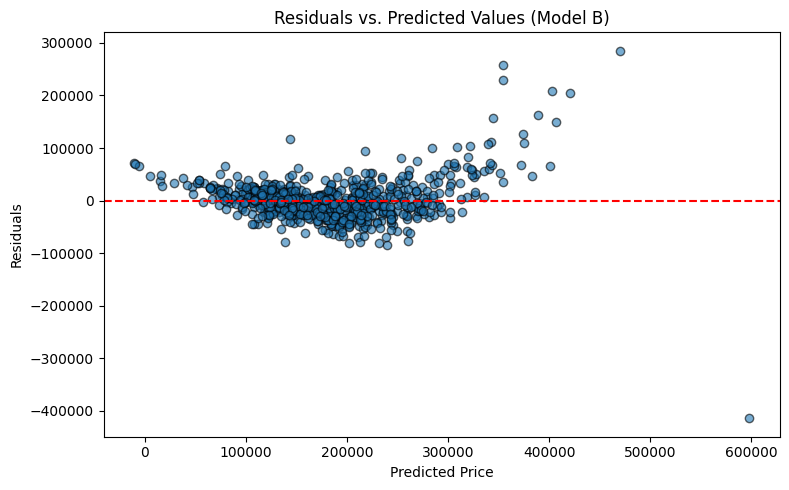

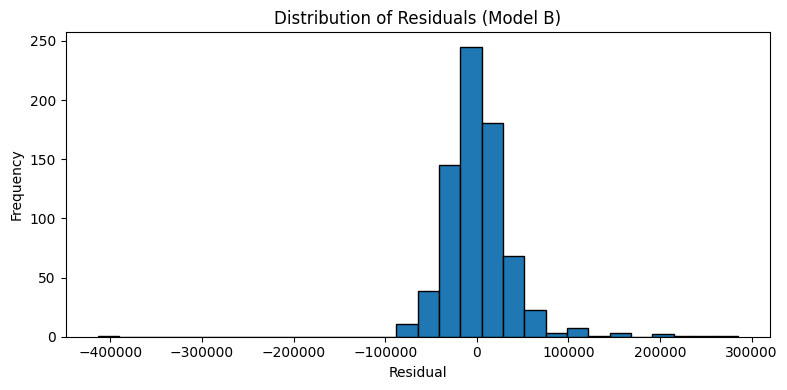


Interpretation:
The residuals vs. predicted plot should show points scattered randomly around zero.
Patterns or curved shapes may indicate that the model is missing a nonlinear relationship.
The histogram should look roughly bell-shaped and centered around zero.
Skew or heavy tails may suggest outliers or non-normal errors, which can affect inference.
Together, these plots help assess whether linear regression assumptions are reasonable.


In [16]:
# STEP 13: Residual Diagnostics – Full Model (Model B)

import matplotlib.pyplot as plt

# Compute residuals
residuals = y_test_full - y_pred_full

# Residuals vs. Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_full, residuals, alpha=0.6, edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values (Model B)")
plt.tight_layout()
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Distribution of Residuals (Model B)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Interpretation:
print("\nInterpretation:")
print("The residuals vs. predicted plot should show points scattered randomly around zero.")
print("Patterns or curved shapes may indicate that the model is missing a nonlinear relationship.")
print("The histogram should look roughly bell-shaped and centered around zero.")
print("Skew or heavy tails may suggest outliers or non-normal errors, which can affect inference.")
print("Together, these plots help assess whether linear regression assumptions are reasonable.")